In [2]:
import yfinance as yf

gold = yf.download("GC=F", start="2016-01-01", end="2026-02-20")

gold.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2016-01-04,1075.099976,1082.500000,1063.199951,1063.400024,143
2016-01-05,1078.400024,1081.500000,1075.300049,1075.599976,82
2016-01-06,1091.900024,1093.699951,1081.599976,1081.599976,52
2016-01-07,1107.699951,1109.400024,1091.599976,1091.599976,122
2016-01-08,1097.800049,1111.099976,1093.000000,1111.099976,98


In [3]:
gold.to_csv(r'C:\Users\workstation\OneDrive\Desktop\My Paython\Gold_Backtest_Project\data\gold_data.csv', index=False)


In [4]:
gold = gold.reset_index()

gold.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,GC=F,GC=F,GC=F,GC=F,GC=F
0,2016-01-04,1075.099976,1082.500000,1063.199951,1063.400024,143
1,2016-01-05,1078.400024,1081.500000,1075.300049,1075.599976,82
2,2016-01-06,1091.900024,1093.699951,1081.599976,1081.599976,52
3,2016-01-07,1107.699951,1109.400024,1091.599976,1091.599976,122
4,2016-01-08,1097.800049,1111.099976,1093.000000,1111.099976,98


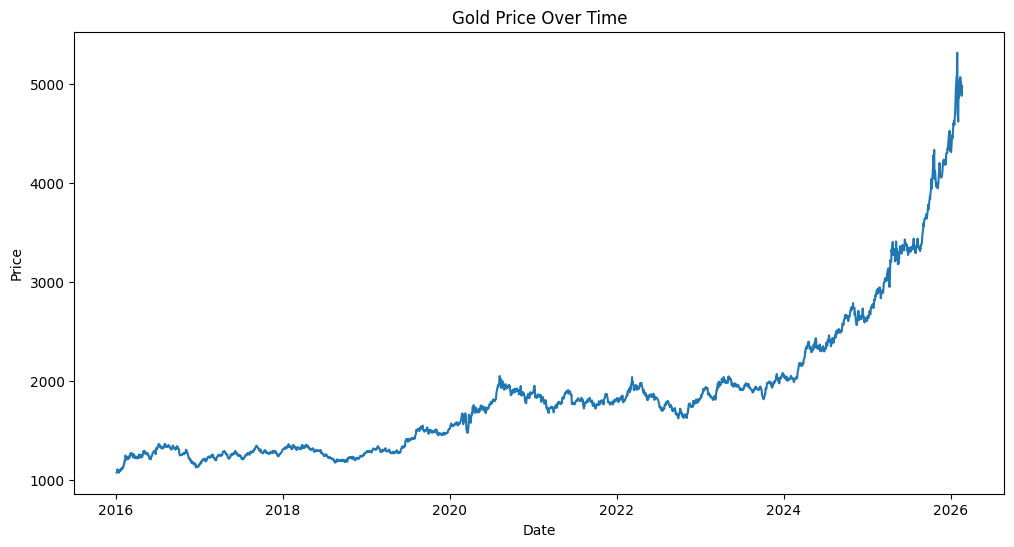

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(gold['Date'], gold['Close'])
plt.title("Gold Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [6]:
gold['MA50'] = gold['Close'].rolling(window=50).mean()
gold['MA200'] = gold['Close'].rolling(window=200).mean()

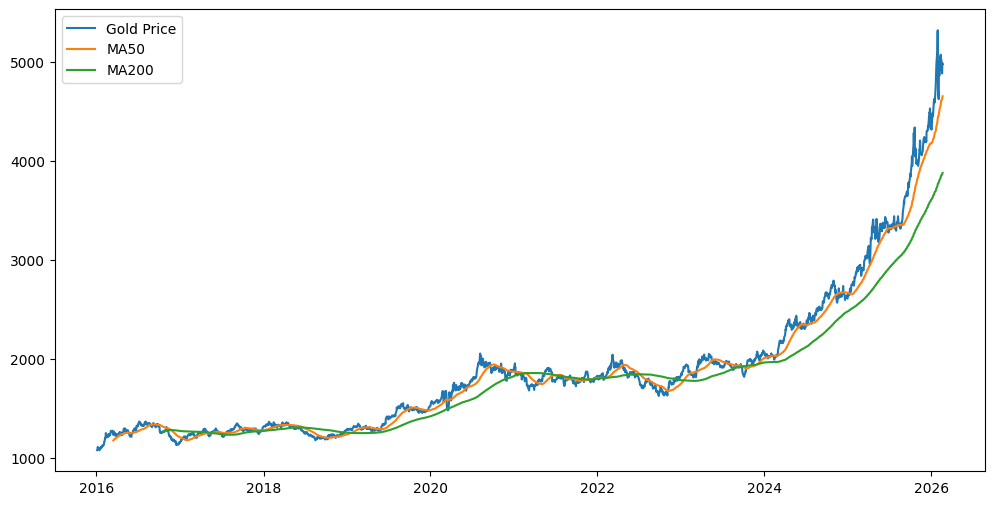

In [7]:
plt.figure(figsize=(12,6))

plt.plot(gold['Date'], gold['Close'], label='Gold Price')
plt.plot(gold['Date'], gold['MA50'], label='MA50')
plt.plot(gold['Date'], gold['MA200'], label='MA200')

plt.legend()
plt.show()

In [8]:
gold['Signal'] = 0

In [9]:
gold.loc[gold['MA50'] > gold['MA200'], 'Signal'] = 1

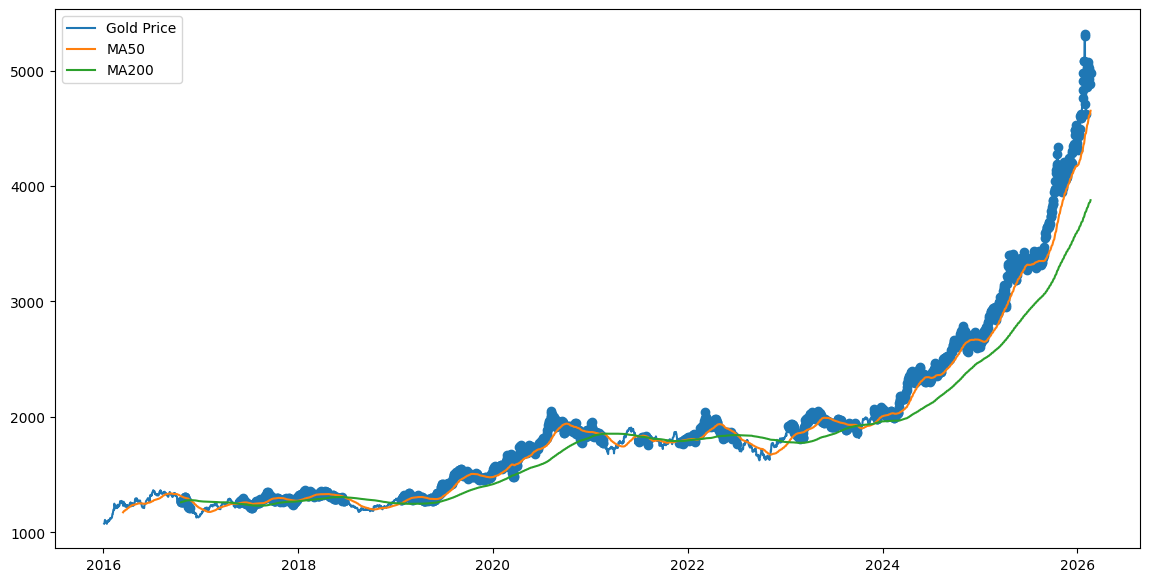

In [10]:
plt.figure(figsize=(14,7))

plt.plot(gold['Date'], gold['Close'], label='Gold Price')
plt.plot(gold['Date'], gold['MA50'], label='MA50')
plt.plot(gold['Date'], gold['MA200'], label='MA200')

buy_signals = gold[gold['Signal'] == 1]

plt.scatter(buy_signals['Date'], buy_signals['Close'])

plt.legend()
plt.show()

In [11]:
gold['Return'] = gold['Close'].pct_change()
gold['Strategy_Return'] = gold['Return'] * gold['Signal']
gold['Cumulative_Market'] = (1 + gold['Return']).cumprod()
gold['Cumulative_Strategy'] = (1 + gold['Strategy_Return']).cumprod()

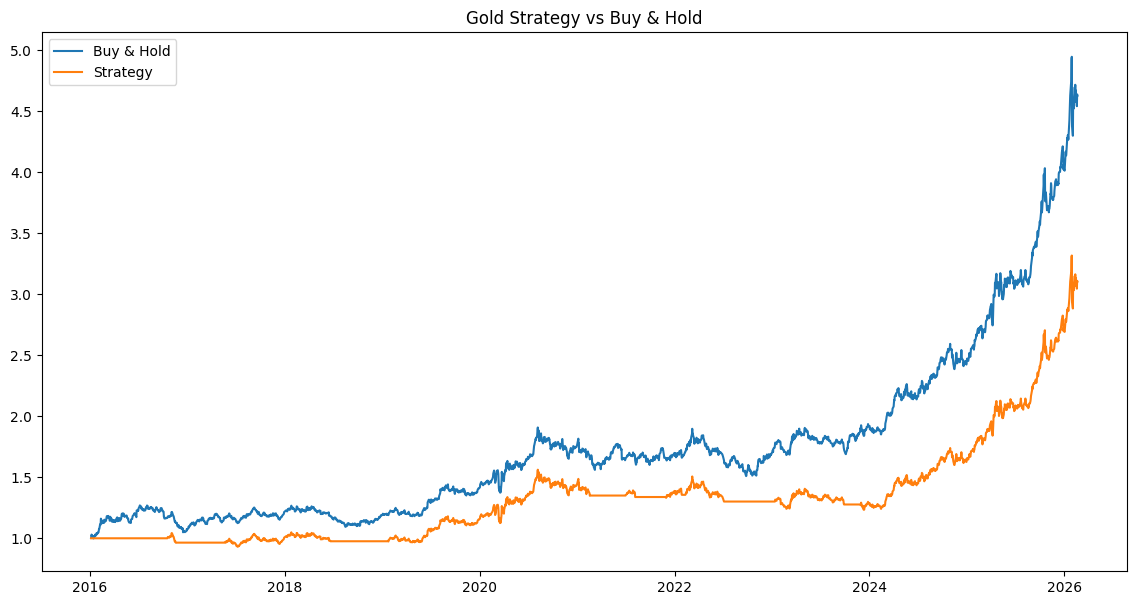

In [12]:
plt.figure(figsize=(14,7))

plt.plot(gold['Date'], gold['Cumulative_Market'], label='Buy & Hold')
plt.plot(gold['Date'], gold['Cumulative_Strategy'], label='Strategy')

plt.legend()
plt.title("Gold Strategy vs Buy & Hold")
plt.show()

In [13]:
market_return = gold['Cumulative_Market'].iloc[-1]
strategy_return = gold['Cumulative_Strategy'].iloc[-1]

print("Market Return:", round((market_return - 1)*100,2), "%")
print("Strategy Return:", round((strategy_return - 1)*100,2), "%")

Market Return: 362.83 %
Strategy Return: 210.41 %


In [14]:
gold['Position'] = gold['Signal'].diff()

In [15]:
buy_points = gold[gold['Position'] == 1]

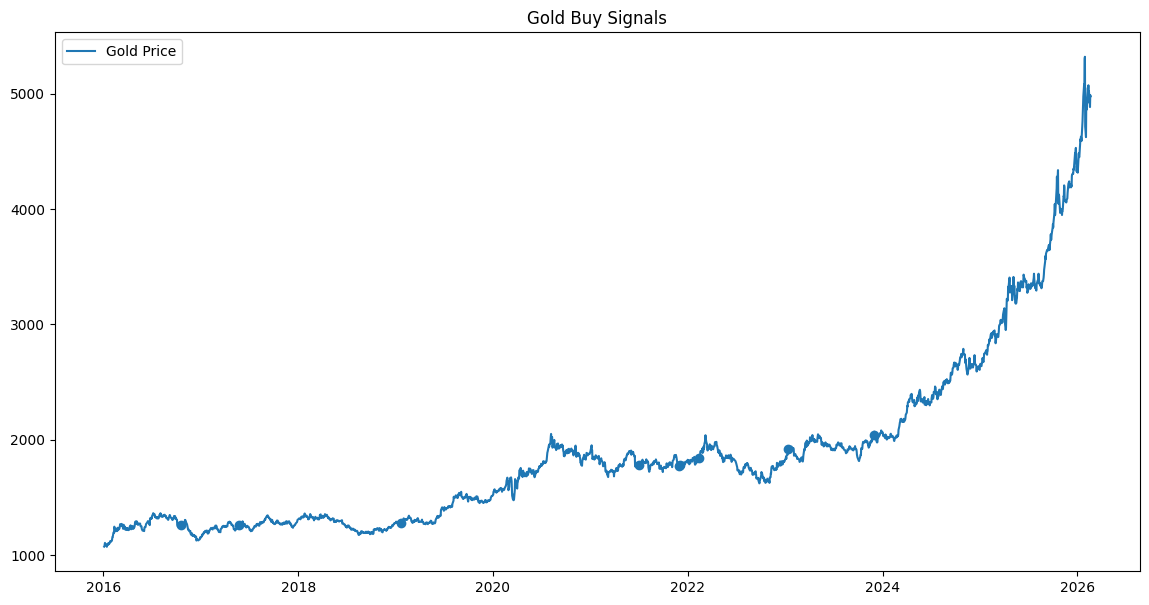

In [16]:
plt.figure(figsize=(14,7))

plt.plot(gold['Date'], gold['Close'], label='Gold Price')

plt.scatter(buy_points['Date'],
            buy_points['Close'])

plt.legend()
plt.title("Gold Buy Signals")
plt.show()

In [17]:
gold['Peak'] = gold['Cumulative_Strategy'].cummax()

gold['Drawdown'] = (
    gold['Cumulative_Strategy'] - gold['Peak']
) / gold['Peak']

max_drawdown = gold['Drawdown'].min()

print("Max Drawdown:", round(max_drawdown*100,2), "%")

Max Drawdown: -21.01 %


In [18]:
gold['Year'] = gold['Date'].dt.year

yearly_returns = gold.groupby('Year')['Return'].sum()

print(yearly_returns.sort_values(ascending=False).head())

Year
2025    0.519307
2024    0.254142
2020    0.242921
2019    0.179522
2026    0.153897
Name: Return, dtype: float64


In [19]:
gold.to_csv(
r"C:\Users\workstation\OneDrive\Desktop\My Paython\Gold_Backtest_Project\data\gold_final_analysis.csv",
index=False
)